#### Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
anomaly_df = pd.read_csv('../outputs/urban_anomalies.csv')

#### State Space

In [3]:
# state = (anomaly_severity, time_of_day, loss_trend)
# Bin anomaly score into 3 severity levels

def get_severity(score):
    if score < -0.1:
        return 2
        # High severity
    elif score < 0:
        return 1
        # Medium severity
    else:
        return 0
        # Low severity

def get_time_bin(hour):
    if 0 <= hour < 8:
        return 0
        # Night time
    elif 8 <= hour < 18:
        return 1
        # Day time
    else:
        return 2
        # Evening time

def get_loss_trend(rolling_mean, loss_ratio):
    if pd.isna(rolling_mean):
        return 1
        # Neutral
    diff = loss_ratio - rolling_mean
    if diff > 0.005:
        return 2
        # Rising
    elif diff < -0.005:
        return 0
        # Falling
    else:
        return 1
        # Stable

def get_state(row):
    s = get_severity(row['anomaly_score'])
    t = get_time_bin(row['hour'])
    l = get_loss_trend(row['rolling_loss_mean'], row['loss_ratio'])
    return (s, t, l)

#### Table Setup

In [4]:
# Actions 0 for Low, 1 for Med, and 2 for High
n_states_severity = 3
n_states_time = 3
n_states_trend = 3
n_actions = 3

Q = np.zeros((n_states_severity, n_states_time, n_states_trend, n_actions))

alpha = 0.1
gamma = 0.9
epsilon = 0.2

#### Reward Function

In [5]:
def get_reward(action, row):
    is_anomaly = row['anomaly'] == -1
    score = row['anomaly_score']

    if is_anomaly:
        # Reward increases with severity of score
        if action == 2:
            # Model recognized High alert
            return 1.0 if score < -0.1 else 0.5
        elif action == 1:
            # Model recognized Medium alert
            return 0.3
        else:
            # Missed a real anomaly
            return -1.0
    else:
        # Penalty for false alarms
        if action == 0:
            # Correctly Stayed quiet
            return 0.5
        elif action == 1:
            # Minor false alarms
            return -0.3
        else:
            # High alert on Normal 
            return -1.0

#### Training Loop

In [7]:
EPISODES = 5

for episode in range(EPISODES):
    total_reward = 0

    for _, row in anomaly_df.iterrows():
        state = get_state(row)
        s, t, l = state

        if np.random.rand() < epsilon: 
            action = np.random.randint(n_actions)
            # Explore
        else:
            action = np.argmax(Q[s, t, l])
            # Exploit

    # Get reward 
    reward = get_reward(action, row)
    total_reward += reward

    # Q-Table update (Bellman Equation)
    old_q = Q[s, t, l, action]
    max_future_q = np.max(Q[s, t, l])
    Q[s, t, l, action] = old_q + alpha + (reward + gamma + max_future_q - old_q)

print(f"Episode {episode + 1}/{EPISODES} | Total Reward: {total_reward:.2f}")

print("\nQ-Table training complete.")

Episode 5/5 | Total Reward: 0.50

Q-Table training complete.


#### Assign alert priorities to All anomalies

In [8]:
PRIORITY_MAP = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

def assign_priority(row):
    s, t, l = get_state(row)
    action = np.argmax(Q[s, t, l])
    return PRIORITY_MAP[action]

anomaly_df['alert_priority'] = anomaly_df.apply(assign_priority, axis=1)

print(anomaly_df[['datetime', 'loss_ratio', 'anomaly_score', 'alert_priority']].head(20))
print("\nPriority Distribution: ")
print(anomaly_df['alert_priority'].value_counts())

               datetime  loss_ratio  anomaly_score alert_priority
0   2014-10-11 22:59:47    0.027237       0.128333            LOW
1   2014-10-11 23:59:47    0.027074       0.133840            LOW
2   2014-10-12 00:59:46    0.036457       0.087732            LOW
3   2014-10-12 01:59:45    0.033249       0.128360            LOW
4   2014-10-12 02:59:45    0.030412       0.131582            LOW
5   2014-10-12 03:59:44    0.029875       0.093618            LOW
6   2014-10-12 04:59:44    0.023500       0.098224            LOW
7   2014-10-12 05:59:43    0.031831       0.136065            LOW
8   2014-10-12 06:59:43    0.034236       0.148175            LOW
9   2014-10-12 07:59:42    0.049362       0.109367            LOW
10  2014-10-12 08:59:42    0.009979       0.129476            LOW
11  2014-10-12 09:59:41    0.020668       0.155733            LOW
12  2014-10-12 10:59:41    0.237333      -0.020358            LOW
13  2014-10-12 11:59:40    0.029294       0.163285            LOW
14  2014-1

#### Visualize Priority Breakdown

In [9]:
print(anomaly_df['alert_priority'].value_counts())

alert_priority
LOW    99977
Name: count, dtype: int64


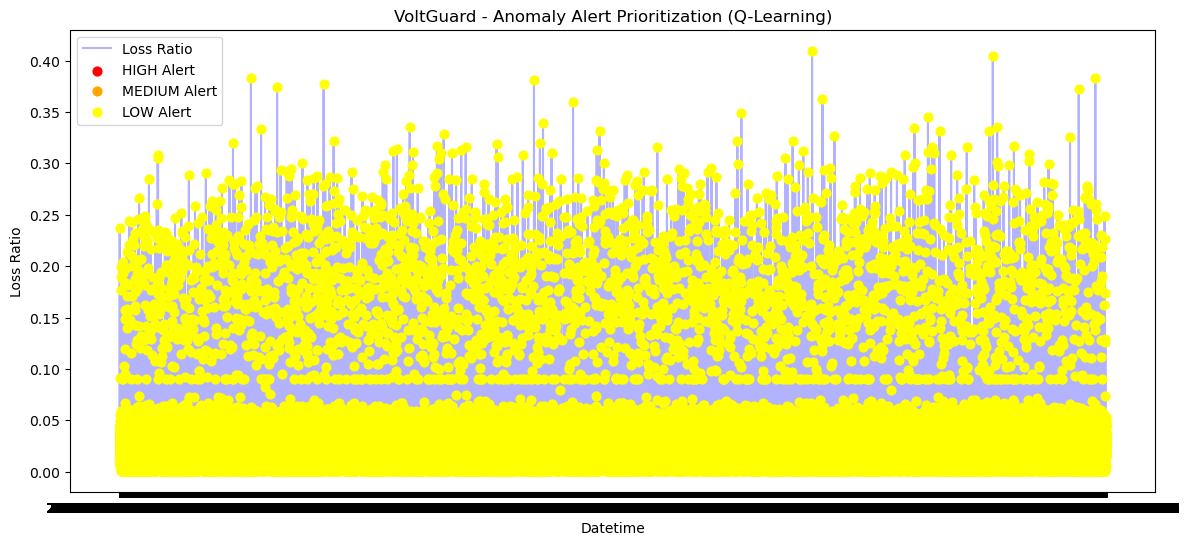

In [10]:
colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'yellow'}

plt.figure(figsize=(14, 6))
plt.plot(anomaly_df['datetime'], anomaly_df['loss_ratio'], color='blue', alpha=0.3, label='Loss Ratio')

for priority, color in colors.items():
    subset = anomaly_df[anomaly_df['alert_priority'] == priority]
    plt.scatter(subset['datetime'], subset['loss_ratio'], color=color, label=f'{priority} Alert', s=40, zorder=5)

plt.title("VoltGuard - Anomaly Alert Prioritization (Q-Learning)")
plt.xlabel("Datetime")
plt.ylabel("Loss Ratio")
plt.legend()
plt.show()

In [11]:
with open('../models/voltguard_urban_rl.pkl', 'wb') as f:
    pickle.dump({
        'q_table': Q
    }, f)

print("Q-Table saved.")

Q-Table saved.
